In [30]:
import xarray as xr
import numpy as np
import pandas as pd
import easyclimate as ecl
import matplotlib.pyplot as plt

<xarray.DataArray 'time' (time: 13008)> Size: 104kB
array(['1991-01-01T00:00:00', '1991-01-02T00:00:00', '1991-01-03T00:00:00',
       ..., '2026-08-13T00:00:00', '2026-08-14T00:00:00',
       '2026-08-15T00:00:00'], shape=(13008,), dtype='datetime64[s]')
Coordinates:
  * time     (time) datetime64[s] 104kB 1991-01-01 1991-01-02 ... 2026-08-15


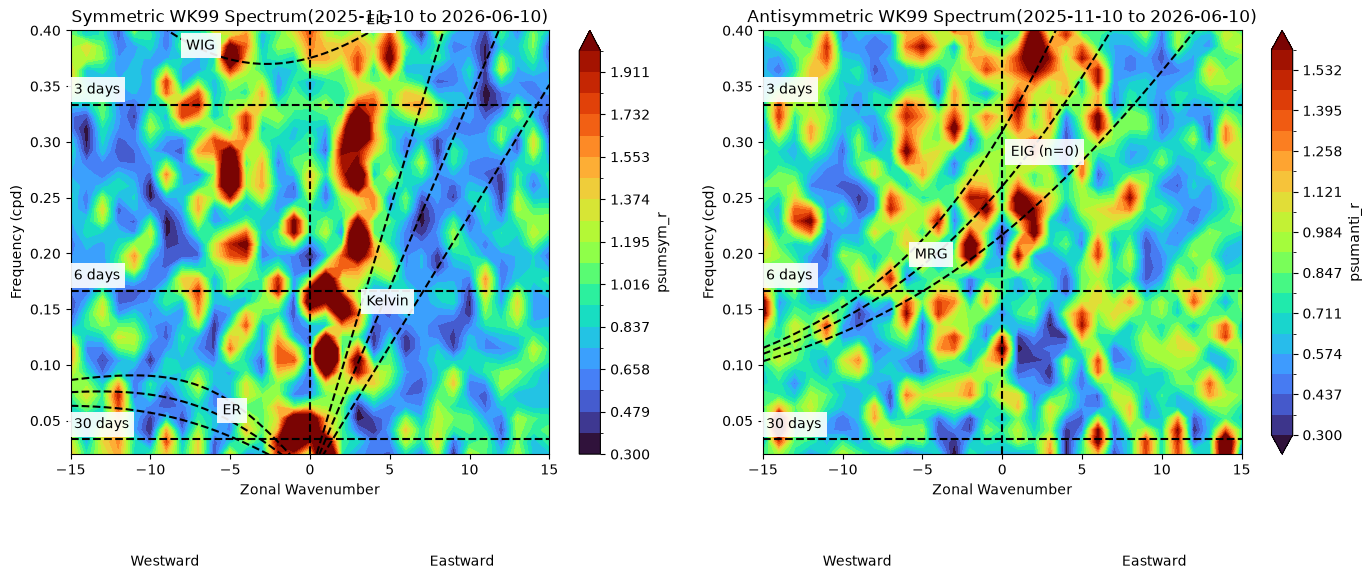

In [31]:

###Plotting WK99

#data in wrong format
ds=xr.open_dataset(r"C:\Users\norna\Downloads\olr.cbo-1deg.day.anom_2.nc", decode_times=False)
time_values=ds['time'].values
valid_mask=(time_values >= 0)&(time_values < 1e10) 
ds=ds.isel(time=valid_mask)
time_actual=pd.to_datetime(ds['time'].values,unit='h',origin='1800-01-01')
ds=ds.assign_coords(time=time_actual)
print(ds['olr']['time'])
data=ds['olr'].sel(time=slice('2025-11-10','2026-06-10')).sel(lat=slice(15,-15),lon=slice(60,180))
data=data.interpolate_na(dim="time",method="linear").ffill(dim="time").bfill(dim="time")


NT=data.shape[0]
SEG=96
SKIP=60
#easyclimate error fix
n_segs=(NT-SEG)//(SEG-SKIP)+1
NT_use=SEG+(n_segs-1)*(SEG-SKIP)
data_spectrum=data.isel(time=slice(0, NT_use)) 


olr_cleaned=ecl.field.equatorial_wave.wk_spectra.remove_dominant_signals(data_spectrum,1,96,60)
decomposed_data=ecl.field.equatorial_wave.wk_spectra.decompose_symasym(olr_cleaned,lat_dim="lat")
spectral_result=ecl.field.equatorial_wave.wk_spectra.calc_spectral_coefficients(decomposed_data,1,96,60)

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,6))
#sym
spectral_result["psumsym_r"].plot.contourf(ax=ax1,x="k",y="freq",cmap="turbo",levels=np.linspace(0.3,2,20))
ecl.field.equatorial_wave.wk_spectra.draw_wk_sym_analysis(max_freq=0.4,max_wn=15,ax=ax1)
ax1.set_title("Symmetric WK99 Spectrum(2025-11-10 to 2026-06-10)")
ax1.set_xlabel("Zonal Wavenumber")
ax1.set_ylabel("Frequency (cpd)")

#anti
spectral_result["psumanti_r"].plot.contourf(ax=ax2,x="k",y="freq",cmap="turbo",levels=np.linspace(0.3,1.6,20))
ecl.field.equatorial_wave.wk_spectra.draw_wk_anti_analysis(max_freq=0.4,max_wn=15,ax=ax2)
ax2.set_title("Antisymmetric WK99 Spectrum(2025-11-10 to 2026-06-10)")
ax2.set_xlabel("Zonal Wavenumber")
ax2.set_ylabel("Frequency (cpd)")

plt.tight_layout()
plt.show()

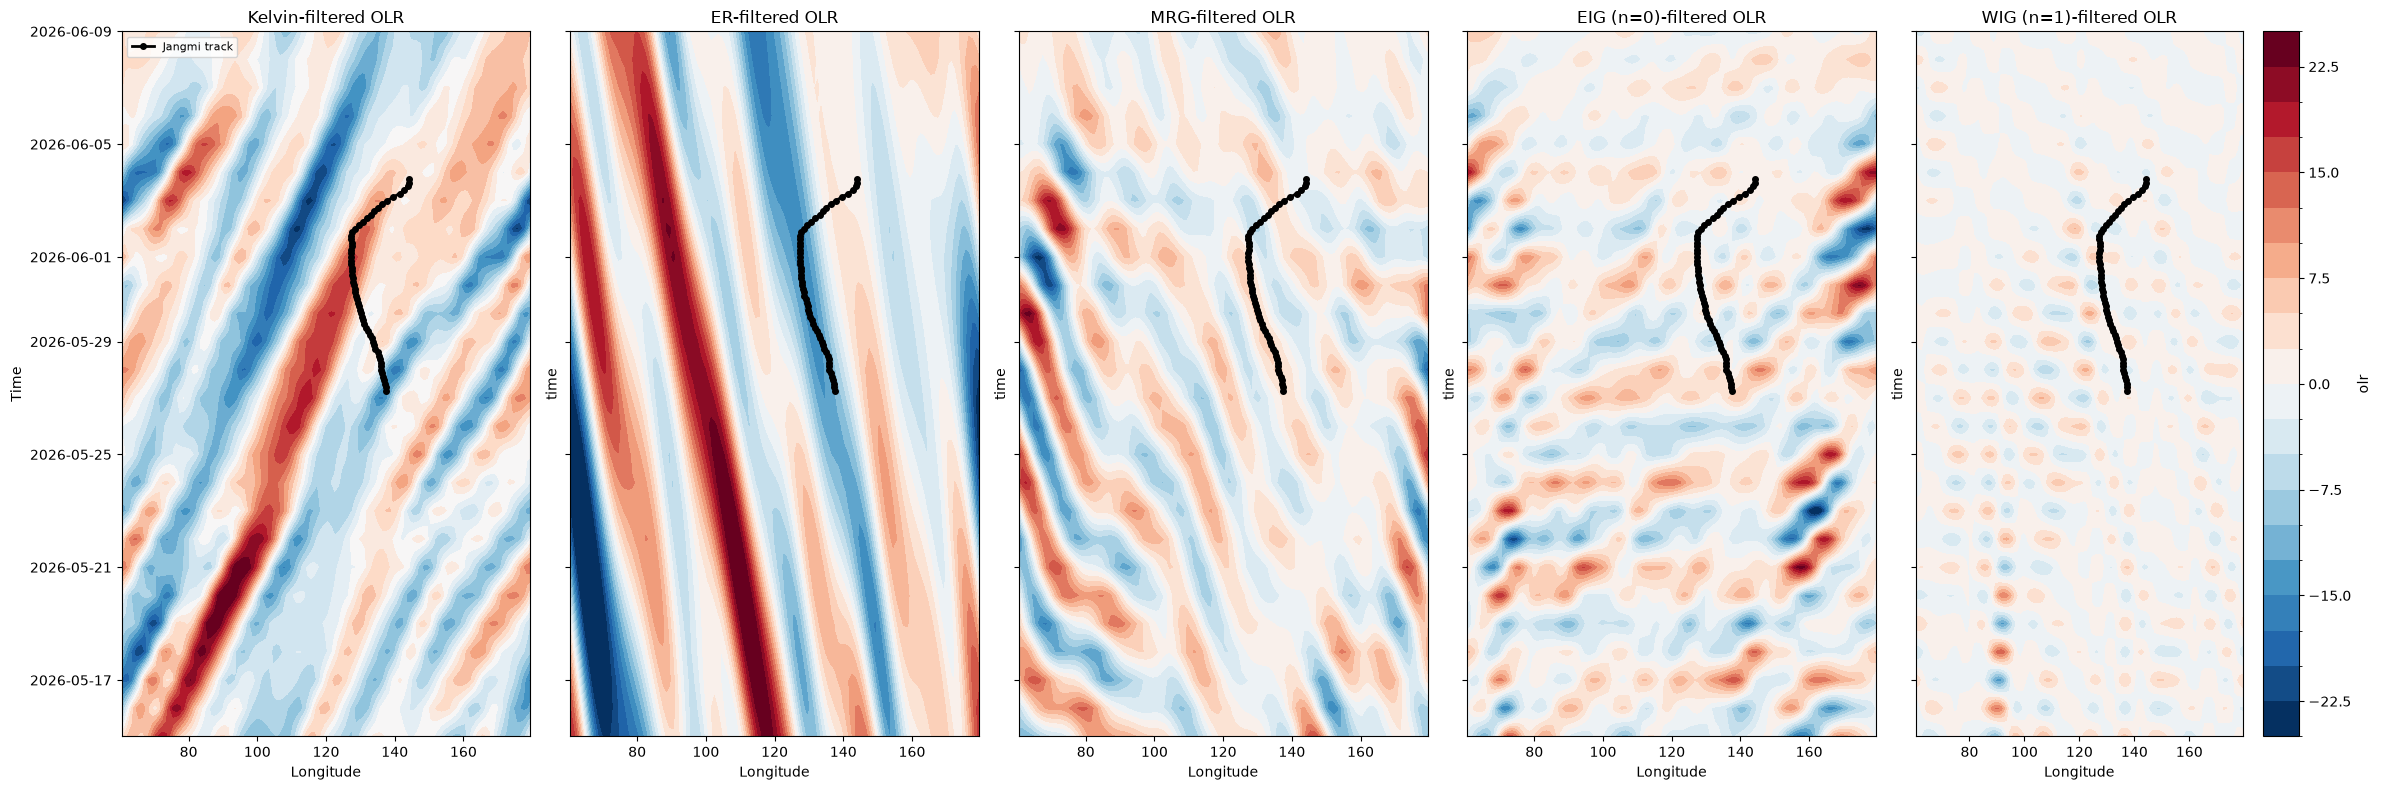

In [32]:
###CCEW Hovmollers with Jangmi track overlaid
import matplotlib.dates as mdates
if data.sizes["time"] % 2 != 0:
    data = data.isel(time=slice(0, -1))


# Kelvin wave
k_fil=ecl.filter.kf_filter.kf_filter_kelvin_wave(data,steps_per_day=1,tMin=2.5,tMax=20,kMin=1,kMax=14,hMin=8,hMax=90)

# Equatorial Rossby (ER) wave
er_fil=ecl.filter.kf_filter.kf_filter_er_wave( data,steps_per_day=1,tMin=9.7,tMax=48,kMin=-10,kMax=-1,hMin=8,hMax=90)

# Mixed Rossby-Gravity (MRG) wave
m_fil=ecl.filter.kf_filter.kf_filter_mrg_wave(data,steps_per_day=1,tMin=3,tMax=9.6,kMin=-10,kMax=-1,hMin=8,hMax=90)

eig_fil=ecl.filter.kf_filter.kf_filter_wheeler_and_kiladis_1999(data,steps_per_day=1,tMin=0.5,tMax=5.3,kMin=0,kMax=14,hMin=8,hMax=90,waveName="ig0")

# Westward inertio-gravity wave, n=1
w_fil=ecl.filter.kf_filter.kf_filter_wheeler_and_kiladis_1999(data,steps_per_day=1,tMin=1.25,tMax=3,kMin=-15,kMax=-1,hMin=12,hMax=90,waveName="ig1")

##Cylcone track
from io import StringIO

raw = """BASIN	ISO_TIME_________	NATURE	LAT	LON	USA WIND	USA PRES
degrees north	degrees east	kts	mb
WP	2026-05-27 06:00:00	NR	9.60	137.50	25	1003
WP	09:00:00	NR	9.90	137.40	25	1003
WP	12:00:00	NR	10.30	137.20	25	1003
WP	15:00:00	NR	11.00	137.00	27	1002
WP	18:00:00	NR	11.70	136.70	29	1000
WP	21:00:00	NR	12.30	136.30	29	1001
WP	2026-05-28 00:00:00	NR	12.70	135.90	29	1001
WP	03:00:00	NR	12.90	135.90	29	1000
WP	06:00:00	NR	13.00	135.90	29	998
WP	09:00:00	NR	13.40	135.80	32	998
WP	12:00:00	NR	13.80	135.50	35	998
WP	15:00:00	NR	14.30	135.00	37	998
WP	18:00:00	NR	14.70	134.40	39	997
WP	21:00:00	NR	15.10	134.00	39	997
WP	2026-05-29 00:00:00	NR	15.40	133.70	39	997
WP	03:00:00	NR	15.70	133.30	39	997
WP	06:00:00	NR	15.90	132.80	39	997
WP	09:00:00	NR	16.20	132.30	42	996
WP	12:00:00	NR	16.50	131.70	45	995
WP	15:00:00	NR	16.60	131.20	48	992
WP	18:00:00	NR	16.70	130.80	51	989
WP	21:00:00	NR	17.10	130.40	53	986
WP	2026-05-30 00:00:00	NR	17.50	130.10	54	983
WP	03:00:00	NR	17.90	129.80	59	981
WP	06:00:00	NR	18.30	129.60	64	979
WP	09:00:00	NR	18.80	129.30	64	979
WP	12:00:00	NR	19.30	129.00	64	979
WP	15:00:00	NR	19.70	128.70	64	979
WP	18:00:00	NR	20.10	128.50	64	978
WP	21:00:00	NR	20.50	128.30	67	978
WP	2026-05-31 00:00:00	NR	20.90	128.10	70	977
WP	03:00:00	NR	21.30	127.90	70	977
WP	06:00:00	NR	21.80	127.80	70	976
WP	09:00:00	NR	22.30	127.70	72	975
WP	12:00:00	NR	22.80	127.70	74	973
WP	15:00:00	NR	23.20	127.60	72	975
WP	18:00:00	NR	23.60	127.40	70	976
WP	21:00:00	NR	24.00	127.30	67	977
WP	2026-06-01 00:00:00	NR	24.50	127.30	64	978
WP	03:00:00	NR	25.00	127.30	62	979
WP	06:00:00	NR	25.60	127.40	60	979
WP	09:00:00	NR	26.10	127.50	57	981
WP	12:00:00	NR	26.70	127.50	54	982
WP	15:00:00	NR	27.30	127.30	54	983
WP	18:00:00	NR	27.90	127.30	54	983
WP	21:00:00	NR	28.50	127.70	53	985
WP	2026-06-02 00:00:00	NR	29.10	128.50	51	986
WP	03:00:00	NR	29.90	129.50	51	983
WP	06:00:00	NR	30.70	130.70	51	980
WP	09:00:00	NR	31.50	131.90	51	982
WP	12:00:00	NR	32.20	133.10	51	984
WP	15:00:00	NR	32.80	134.00	51	984
WP	18:00:00	NR	33.30	135.00	51	983
WP	21:00:00	NR	33.80	136.30	51	984
WP	2026-06-03 00:00:00	NR	34.20	137.80	51	985
WP	03:00:00	NR	34.50	139.60	51	984
WP	06:00:00	NR	34.90	141.40	51	983
WP	09:00:00	NR	35.90	142.80	51	983
WP	12:00:00	NR	36.70	143.80	51	983
WP	15:00:00	NR	36.80	144.10	48	984
WP	18:00:00	NR	36.50	144.10	45	984
"""

df=pd.read_csv(StringIO(raw),sep='\t',skiprows=2,header=None,names=['basin','iso_time','nature','lat','lon','wind','pres'])
full_date_mask=df['iso_time'].str.contains('-')
df['date']=None
df.loc[full_date_mask,'date']=df.loc[full_date_mask,'iso_time'].str.split(' ').str[0]
df['date']=df['date'].ffill()
df['time']=pd.to_datetime(df['date']+' '+df['iso_time'].str.split(' ').str[-1])

jangmi_track=df[['time','lat','lon','wind','pres']].copy()
jangmi_track['lat']=jangmi_track['lat'].astype(float)
jangmi_track['lon']=jangmi_track['lon'].astype(float)


##Hovmoller

lat_band = slice(20,5)
wave_fields={"Kelvin":k_fil,"ER":er_fil,"MRG":m_fil,"EIG (n=0)":eig_fil,"WIG (n=1)":w_fil}

hov_window=slice("2026-05-15","2026-06-10")  #for genesis

fig,axes=plt.subplots(1,5,figsize=(24,8),sharey=True)

for ax,(name,field) in zip(axes,wave_fields.items()):
    hov=field.sel(lat=lat_band).mean(dim="lat").sel(time=hov_window)
    hov.plot.contourf(ax=ax,x="lon",y="time",cmap="RdBu_r",levels=np.linspace(-25, 25, 21),add_colorbar=(name=="WIG (n=1)"))
    ax.plot(jangmi_track["lon"],jangmi_track["time"],color="black",marker="o",linewidth=2,markersize=4,label="Jangmi track")
    ax.set_title(f"{name}-filtered OLR")
    ax.set_xlabel("Longitude")
    if name == "Kelvin":
        ax.set_ylabel("Time")
        ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()


C:\Users\norna\AppData\Local\Temp\ipykernel_19904\2483603113.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


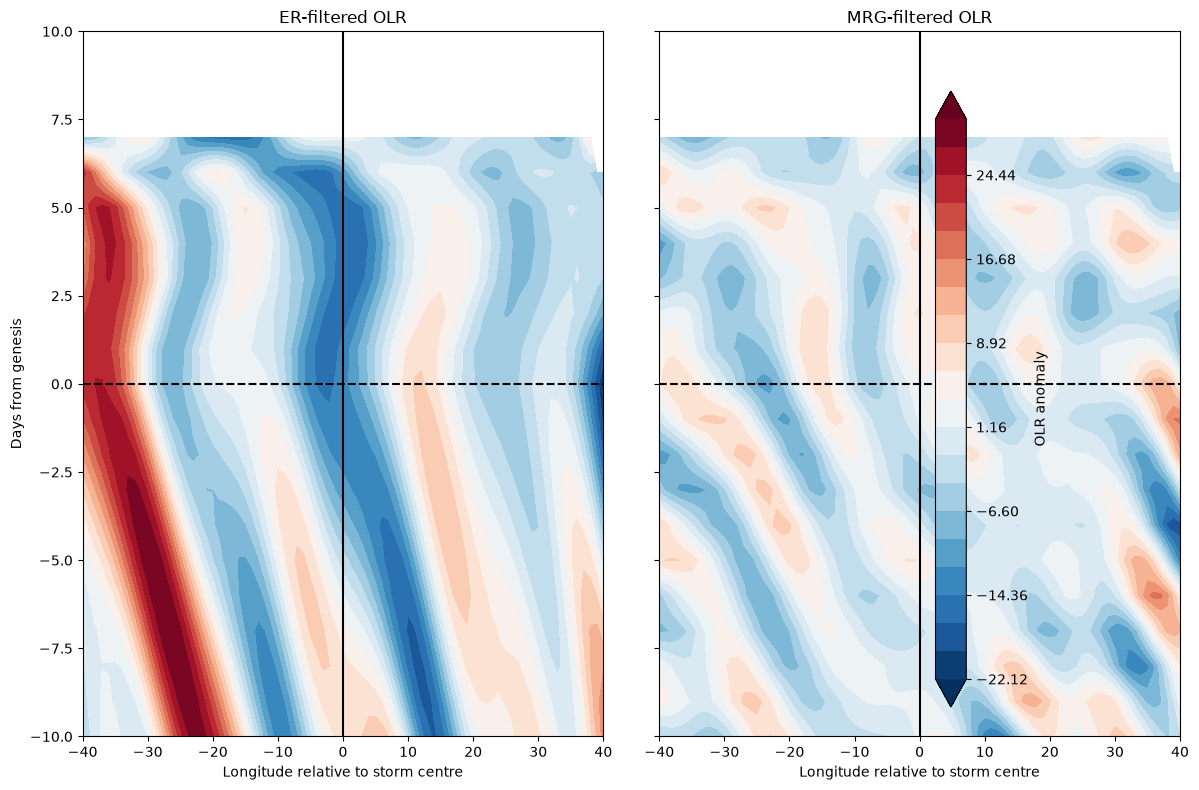

In [33]:
# Jangmi genesis point
jt=jangmi_track.copy()
jt["time"]=pd.to_datetime(jt["time"])
jt=jt.sort_values("time")

gen_time=jt.iloc[0]["time"]
gen_lon=jt.iloc[0]["lon"]
gen_lat=jt.iloc[0]["lat"]

track_daily=(jt.set_index("time")[["lat","lon"]].reindex(pd.date_range(jt["time"].min(),jt["time"].max(),freq="1D")).interpolate(method="time"))


def c_hov(field,lon_range=40,name=""):

    lat=field["lat"].values
    lat_idx=np.where((lat>=5)&(lat<=20))[0]
    data=field.isel(lat=lat_idx).mean(dim="lat")

    #relative long
    lon=data["lon"].values
    dlon=lon[1]-lon[0]
    rel_lon=np.arange(-lon_range,lon_range+dlon,dlon)
    t=np.arange(-10,11)

    field_times=pd.to_datetime(data["time"].values)

    hov=np.full((len(t),len(rel_lon)),np.nan)

    for i,lag in enumerate(t):

        current_time=gen_time+pd.Timedelta(days=int(lag))

        if lag<0:
            storm_lon=gen_lon

        elif (track_daily.index.min()<=current_time<=track_daily.index.max()):
            pos=track_daily.index.get_indexer([current_time],method="nearest")[0]
            storm_lon=track_daily.iloc[pos]["lon"]

        else:
            continue

        time_diff=np.abs((field_times-current_time).total_seconds())
        time_idx=np.argmin(time_diff)

        row=data.isel(time=time_idx)

        lon=np.asarray(row["lon"].values)
        values=np.asarray(row.values)

        # Convert longitude into distance from centre
        relative_lon=((lon-storm_lon+180)%360)-180
        sort_idx=np.argsort(relative_lon)
        hov[i,:]=np.interp(rel_lon,relative_lon[sort_idx],values[sort_idx],left=np.nan,right=np.nan)

    return xr.DataArray(hov,coords={"lag_days":t,"lon_rel":rel_lon},name=name)


# Make the storm-centred Hovmoller diagrams
er_centered=c_hov(er_fil,name="ER")
mrg_centered=c_hov(m_fil,name="MRG")


# Plot
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,8),sharey=True)

all_values=np.concatenate([er_centered.values.ravel(),mrg_centered.values.ravel()])
levels=np.linspace(np.nanmin(all_values),np.nanmax(all_values),21)
plot1=ax1.contourf(er_centered["lon_rel"],er_centered["lag_days"],er_centered,levels=levels,cmap="RdBu_r",extend="both")
ax1.axvline(0,color="k")
ax1.axhline(0,color="k",ls="--")
ax1.set_title("ER-filtered OLR")
ax1.set_xlabel("Longitude relative to storm centre")

plot2=ax2.contourf(mrg_centered["lon_rel"], mrg_centered["lag_days"],mrg_centered,levels=levels,cmap="RdBu_r",extend="both")
ax2.axvline(0,color="k")
ax2.axhline(0,color="k",ls="--")
ax2.set_title("MRG-filtered OLR")
ax2.set_xlabel("Longitude relative to storm centre")

ax1.set_ylabel("Days from genesis")

fig.colorbar(plot1,ax=(ax1, ax2),label="OLR anomaly")

plt.tight_layout()
plt.show()

In [34]:
###Cyclone speed

#genesis to RI window
pre_gen=jangmi_track[(jangmi_track['time']>='2026-05-25')&(jangmi_track['time']<='2026-05-30')].copy()

#speed in deg/day
pre_gen['dlon_dt']=pre_gen['lon'].diff()/(pre_gen['time'].diff().dt.total_seconds()/86400)

#m/s
pre_gen['zonal_speed']=pre_gen['dlon_dt']*111000/86400*np.cos(np.deg2rad(pre_gen['lat']))

print(pre_gen[['time','lon','dlon_dt','zonal_speed']])

                  time    lon  dlon_dt  zonal_speed
0  2026-05-27 06:00:00  137.5      NaN          NaN
1  2026-05-27 09:00:00  137.4     -0.8    -1.012473
2  2026-05-27 12:00:00  137.2     -1.6    -2.022430
3  2026-05-27 15:00:00  137.0     -1.6    -2.017789
4  2026-05-27 18:00:00  136.7     -2.4    -3.019270
5  2026-05-27 21:00:00  136.3     -3.2    -4.016743
6  2026-05-28 00:00:00  135.9     -3.2    -4.010531
7  2026-05-28 03:00:00  135.9      0.0     0.000000
8  2026-05-28 06:00:00  135.9      0.0     0.000000
9  2026-05-28 09:00:00  135.8     -0.8    -0.999797
10 2026-05-28 12:00:00  135.5     -2.4    -2.994331
11 2026-05-28 15:00:00  135.0     -4.0    -4.979664
12 2026-05-28 18:00:00  134.4     -4.8    -5.964818
13 2026-05-28 21:00:00  134.0     -3.2    -3.969165
14 2026-05-29 00:00:00  133.7     -2.4    -2.972627
15 2026-05-29 03:00:00  133.3     -3.2    -3.957733
16 2026-05-29 06:00:00  132.8     -4.0    -4.942282
17 2026-05-29 09:00:00  132.3     -4.0    -4.934843
18 2026-05-2

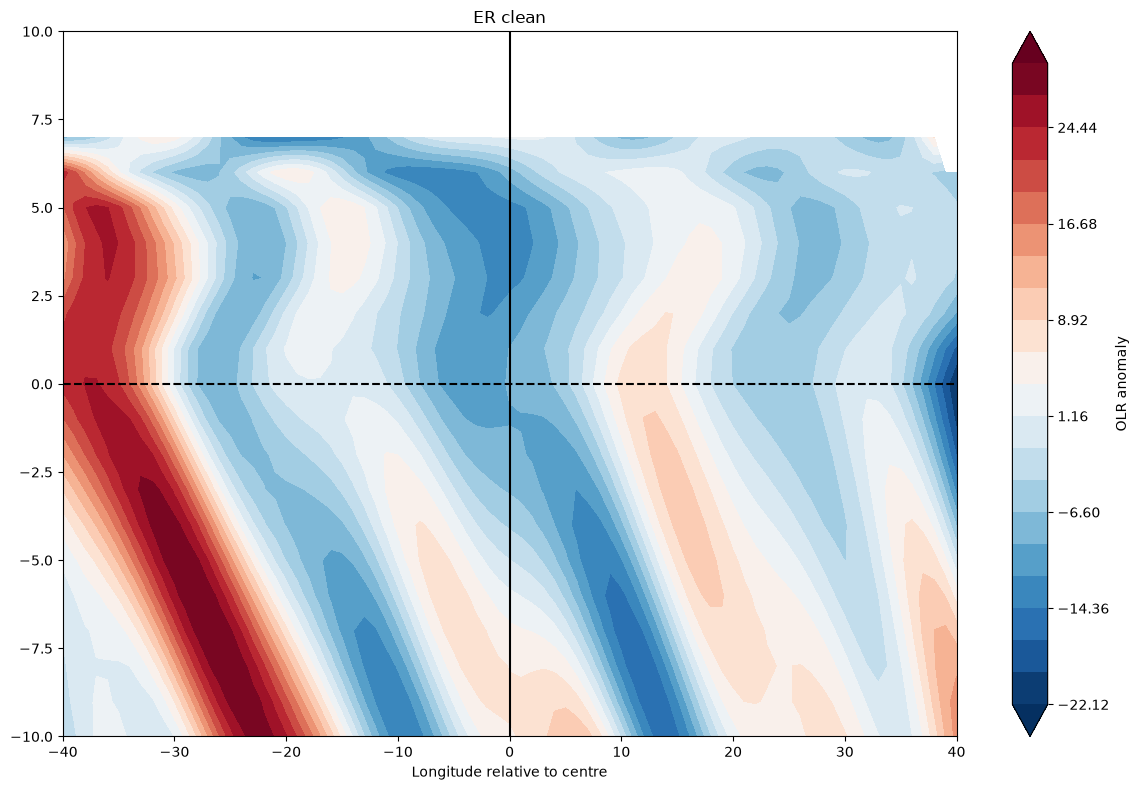

Correlation ER vs ER clean:0.994


In [35]:
###Removing TC signal from OLR/Er data
R=500.0                              #from paper
sigma=R/np.sqrt(2*np.log(2))  #for w=0.5

data_times=pd.to_datetime(data["time"].values)
overlap_times=[t for t in data_times
               if track_daily.index.min()<=t<=track_daily.index.max()]

data_tc_removed=data.copy(deep=True)
lat2d,lon2d=xr.broadcast(data["lat"],data["lon"])

for t in overlap_times:
    pos=track_daily.index.get_indexer([t],method="nearest")[0]
    storm_lat=track_daily["lat"].iloc[pos]
    storm_lon=track_daily["lon"].iloc[pos]
    dy=(lat2d-storm_lat)*111.3
    dx=(lon2d-storm_lon)*111.3*np.cos(np.deg2rad(lat2d))
    r=np.sqrt(dx**2+dy**2)
    w=1-np.exp(-(r**2)/(2*sigma**2))
    data_tc_removed.loc[dict(time=t)]=data_tc_removed.sel(time=t)*w

er_fil_clean=ecl.filter.kf_filter.kf_filter_er_wave(data_tc_removed,steps_per_day=1,tMin=9.7,tMax=48,kMin=-10,kMax=-1,hMin=8, hMax=90)
er_centered_clean=c_hov(er_fil_clean,name="ER_clean")


fig,ax=((12,8))
all_values=np.concatenate([er_centered.values.ravel(),er_centered_clean.values.ravel()])
levels=np.linspace(np.nanmin(all_values),np.nanmax(all_values),21)
fig,ax=plt.subplots(figsize=(12, 8))

cf=ax.contourf(er_centered_clean["lon_rel"],er_centered_clean["lag_days"],er_centered_clean.values,levels=levels,cmap="RdBu_r",extend="both")

ax.axvline(0,color="k")
ax.axhline(0,color="k",ls="--")
ax.set_title("ER clean")
ax.set_xlabel("Longitude relative to centre")
fig.colorbar(cf,ax=ax,label="OLR anomaly")
plt.tight_layout()
plt.show()

mask=~np.isnan(er_centered.values) & ~np.isnan(er_centered_clean.values)
corr=np.corrcoef(er_centered.values[mask],er_centered_clean.values[mask])[0, 1]
print(f"Correlation ER vs ER clean:{corr:.3f}")



In [44]:
###Calculating velocity of ER

er_1d=er_fil_clean.sel(lat=lat_band).mean(dim="lat")
track_window=er_1d.sel(lon=slice(110,150),time=slice("2026-05-20","2026-06-05"))  #for better fit

times=pd.to_datetime(track_window["time"].values)
lons=track_window["lon"].values

trough_lon=np.full(len(times),np.nan)
first_row=track_window.isel(time=0).values
trough_lon[0]=lons[np.nanargmin(first_row)]

search_half_width=15  # degrees
for i in range(1,len(times)):
    row=track_window.isel(time=i).values
    near=np.abs(lons-trough_lon[i-1])<=search_half_width
    if not near.any():
        break
    sub_lons=lons[near]
    sub_vals=row[near]
    if np.all(np.isnan(sub_vals)):
        break
    trough_lon[i]=sub_lons[np.nanargmin(sub_vals)]

valid=~np.isnan(trough_lon)
days=(times[valid]-times[valid][0]).total_seconds()/86400.0
lon_track=trough_lon[valid]

#linear fit
slope_deg_per_day,_=np.polyfit(days, lon_track, 1)

mean_lat=12.5  # centre of lat_band 
v=slope_deg_per_day*111320*np.cos(np.deg2rad(mean_lat))/86400

print(f"ER speed:{v:.2f} m/s")
print(f"Cyclone speed(pre gen to RI):{pre_gen['zonal_speed'].min():.2f} to {pre_gen['zonal_speed'].max():.2f} m/s")
print("Theoretical ER speed:-2.2 to -9.8 m/s")


ER speed:-2.52 m/s
Cyclone speed(pre gen to RI):-5.96 to 0.00 m/s
Theoretical ER speed:-2.2 to -9.8 m/s
